VM KHUMALO 22437888

Project Definition Theme: The 2026 South African Local Government Elections are scheduled for 04 November 2026 (contextually, today is 05 October 2026, 30 days before the election). This notebook implements an evidence-based, technically defensible predictive analytics solution for the eThekwini Metropolitan Municipality.
Analytical Objectives Metro-level party share & coalitions: Project aggregate vote shares/totals and assess potential coalition thresholds. Three-Ward Analysis: Project leading parties in three selected, geographically aligned wards with explicit justification. Party-specific Vote Share: Project individual vote shares/totals for all relevant parties. Voter Turnout: Project the absolute number of voters and turnout percentage for the metro. ML Methodology & Unit of Analysis Instead of treating entire election years as single observations (which would provide only two data points: 2011 and 2021), we leverage individual wards as observations. This provides hundreds of distinct ward-election observations across 2011 and 2021 to train robust Machine Learning models.

importing important libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


Upload the CSV files

Load the CSV files

In [40]:
df1 = pd.read_csv('/content/ETH (1).csv')
df2 = pd.read_csv('/content/ETH (2).csv', encoding='utf-16')
print("df1 loaded shape:", df1.shape)
print("df2 loaded shape:", df2.shape)

df1 loaded shape: (40706, 11)
df2 loaded shape: (24843, 11)


In [9]:
from google.colab import files

uploaded = files.upload()

print("Files uploaded:")
for filename in uploaded.keys():
    print(filename)

Saving ETH (1).csv to ETH (1).csv
Files uploaded:
ETH (1).csv


In [10]:
from google.colab import files

uploaded = files.upload()

print("Files uploaded:")
for filename in uploaded.keys():
    print(filename)

Saving ETH (2).csv to ETH (2).csv
Files uploaded:
ETH (2).csv


In [5]:
files_list = list(uploaded.keys())

print(files_list)

['ETH (1) (1).csv']


In [11]:
files_list = list(uploaded.keys())

print(files_list)

['ETH (2).csv']


Data Understanding

In [16]:
print("/content/ETH (1).csv")
display(df1.head())

print("/content/ETH (2).csv")
display(df2.head())

/content/ETH (1).csv


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,ACADEMIC CONGRESS UNION,0,8/11/2016 12:55:57 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,8/11/2016 12:55:57 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN INDEPENDENT CONGRESS,19,8/11/2016 12:55:57 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN MANTUNGWA COMMUNITY,0,8/11/2016 12:55:57 PM
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN NATIONAL CONGRESS,1157,8/11/2016 12:55:57 PM


/content/ETH (2).csv


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,5/26/2011 4:40:02 PM
1,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,5/26/2011 4:40:02 PM
2,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN NATIONAL CONGRESS,973,5/26/2011 4:40:02 PM
3,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN PEOPLE'S CONVENTION,2,5/26/2011 4:40:02 PM
4,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AZANIAN PEOPLE'S ORGANISATION,1,5/26/2011 4:40:02 PM


In [17]:
print("===== FIRST ELECTION DATA =====")
display(df1.head())

print("===== SECOND ELECTION DATA =====")
display(df2.head())

===== FIRST ELECTION DATA =====


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,ACADEMIC CONGRESS UNION,0,8/11/2016 12:55:57 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,8/11/2016 12:55:57 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN INDEPENDENT CONGRESS,19,8/11/2016 12:55:57 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN MANTUNGWA COMMUNITY,0,8/11/2016 12:55:57 PM
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN NATIONAL CONGRESS,1157,8/11/2016 12:55:57 PM


===== SECOND ELECTION DATA =====


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,5/26/2011 4:40:02 PM
1,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,5/26/2011 4:40:02 PM
2,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN NATIONAL CONGRESS,973,5/26/2011 4:40:02 PM
3,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN PEOPLE'S CONVENTION,2,5/26/2011 4:40:02 PM
4,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AZANIAN PEOPLE'S ORGANISATION,1,5/26/2011 4:40:02 PM


Last rows

In [18]:
display(df1.tail())
display(df2.tail())

,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
40701,KwaZulu-Natal,ETH - eThekwini,Ward 59500110,43362288,MT ROYAL PRIMARY SCHOOL,2466,Ward,31,MINORITY FRONT,0,8/11/2016 12:55:57 PM
40702,KwaZulu-Natal,ETH - eThekwini,Ward 59500110,43362288,MT ROYAL PRIMARY SCHOOL,2466,Ward,31,PAN AFRICANIST CONGRESS OF AZANIA,0,8/11/2016 12:55:57 PM
40703,KwaZulu-Natal,ETH - eThekwini,Ward 59500110,43362288,MT ROYAL PRIMARY SCHOOL,2466,Ward,31,TRULY ALLIANCE,1,8/11/2016 12:55:57 PM
40704,KwaZulu-Natal,ETH - eThekwini,Ward 59500110,43362288,MT ROYAL PRIMARY SCHOOL,2466,Ward,31,UNITED PEOPLES PARTY,1,8/11/2016 12:55:57 PM
40705,KwaZulu-Natal,ETH - eThekwini,Ward 59500110,43362288,MT ROYAL PRIMARY SCHOOL,2466,Ward,31,VRYHEIDSFRONT PLUS,0,8/11/2016 12:55:57 PM


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
24838,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500103,43583980,KWANYUSWA ZCC CHURCH,576,Ward,0,NATIONAL FREEDOM PARTY,15,5/26/2011 4:40:02 PM
24839,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500103,43583980,KWANYUSWA ZCC CHURCH,576,Ward,0,SOCIALIST GREEN COALITION,0,5/26/2011 4:40:02 PM
24840,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500103,43583980,KWANYUSWA ZCC CHURCH,576,Ward,0,TRULY ALLIANCE,2,5/26/2011 4:40:02 PM
24841,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500103,43583980,KWANYUSWA ZCC CHURCH,576,Ward,0,UNITED ACTION FRONT,0,5/26/2011 4:40:02 PM
24842,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500103,43583980,KWANYUSWA ZCC CHURCH,576,Ward,0,VRYHEIDSFRONT PLUS,0,5/26/2011 4:40:02 PM


Dimensions

In [19]:

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

Dataset 1 shape: (40706, 11)
Dataset 2 shape: (24843, 11)


Information

In [20]:
print("===== DATASET 1 INFO =====")
df1.info()

print("\n===== DATASET 2 INFO =====")
df2.info()

===== DATASET 1 INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40706 entries, 0 to 40705
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Province           40706 non-null  object
 1   Municipality       40706 non-null  object
 2   Ward               40706 non-null  object
 3   VotingDistrict     40706 non-null  int64 
 4   VotingStationName  40706 non-null  object
 5   RegisteredVoters   40706 non-null  int64 
 6   BallotType         40706 non-null  object
 7   SpoiltVotes        40706 non-null  int64 
 8   PartyName          40706 non-null  object
 9   TotalValidVotes    40706 non-null  int64 
 10  DateGenerated      40706 non-null  object
dtypes: int64(4), object(7)
memory usage: 3.4+ MB

===== DATASET 2 INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24843 entries, 0 to 24842
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------        

Columns

In [21]:
print("Dataset 1 columns:")
print(df1.columns.tolist())

print("\nDataset 2 columns:")
print(df2.columns.tolist())

Dataset 1 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

Dataset 2 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


Descriptive statistics

In [22]:
display(df1.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Province,40706,1,KwaZulu-Natal,40706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Municipality,40706,1,ETH - eThekwini,40706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ward,40706,110,Ward 59500105,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VotingDistrict,40706.0,NaN,NaN,NaN,43420552.208053,104223.467073,43350016.0,43361726.0,43371626.0,43400540.0,44070072.0
VotingStationName,40706,864,ROMAN CATHOLIC CHURCH,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RegisteredVoters,40706.0,NaN,NaN,NaN,2218.242618,1216.222531,101.0,1376.0,2098.0,2827.0,8099.0
BallotType,40706,2,PR,23382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SpoiltVotes,40706.0,NaN,NaN,NaN,29.917383,51.968268,0.0,6.0,17.0,36.0,993.0
PartyName,40706,28,ACADEMIC CONGRESS UNION,1732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalValidVotes,40706.0,NaN,NaN,NaN,54.675109,231.244162,0.0,0.0,1.0,6.0,4175.0


Descriptive statistics

In [23]:
display(df1.describe(include="all").T)
display(df2.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Province,40706,1,KwaZulu-Natal,40706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Municipality,40706,1,ETH - eThekwini,40706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ward,40706,110,Ward 59500105,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VotingDistrict,40706.0,NaN,NaN,NaN,43420552.208053,104223.467073,43350016.0,43361726.0,43371626.0,43400540.0,44070072.0
VotingStationName,40706,864,ROMAN CATHOLIC CHURCH,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RegisteredVoters,40706.0,NaN,NaN,NaN,2218.242618,1216.222531,101.0,1376.0,2098.0,2827.0,8099.0
BallotType,40706,2,PR,23382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SpoiltVotes,40706.0,NaN,NaN,NaN,29.917383,51.968268,0.0,6.0,17.0,36.0,993.0
PartyName,40706,28,ACADEMIC CONGRESS UNION,1732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalValidVotes,40706.0,NaN,NaN,NaN,54.675109,231.244162,0.0,0.0,1.0,6.0,4175.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Province,24843,1,KwaZulu-Natal,24843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Municipality,24843,1,ETH - eThekwini [Durban Metro],24843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ward,24843,103,Ward 59500100,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VotingDistrict,24843.0,NaN,NaN,NaN,43413555.95701,101403.396067,43350016.0,43361614.0,43371435.0,43400146.0,44070072.0
VotingStationName,24843,797,ROMAN CATHOLIC CHURCH,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RegisteredVoters,24843.0,NaN,NaN,NaN,2086.138107,1125.69214,129.0,1268.0,1987.0,2689.0,7712.0
BallotType,24843,2,PR,13617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SpoiltVotes,24843.0,NaN,NaN,NaN,17.688685,20.507079,0.0,5.0,12.0,24.0,297.0
PartyName,24843,19,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalValidVotes,24843.0,NaN,NaN,NaN,78.182224,272.686536,0.0,0.0,2.0,13.0,3577.0


Check Missing Values

In [24]:
print("Missing values - Dataset 1")
display(df1.isnull().sum().sort_values(ascending=False))

print("\nMissing values - Dataset 2")

Missing values - Dataset 1


,0
Province,0
Municipality,0
Ward,0
VotingDistrict,0
VotingStationName,0
RegisteredVoters,0
BallotType,0
SpoiltVotes,0
PartyName,0
TotalValidVotes,0



Missing values - Dataset 2


Check duplicates

In [25]:
print("Duplicate rows - Dataset 1:", df1.duplicated().sum())
print("Duplicate rows - Dataset 2:", df2.duplicated().sum())

Duplicate rows - Dataset 1: 0
Duplicate rows - Dataset 2: 0


Understand the parties

In [26]:
print("Number of unique parties - Dataset 1:",
      df1["PartyName"].nunique())

print("\nParties in Dataset 1:")
display(df1["PartyName"].value_counts())

print("Number of unique parties - Dataset 2:",
      df2["PartyName"].nunique())

print("\nParties in Dataset 2:")
display(df2["PartyName"].value_counts())

Number of unique parties - Dataset 1: 28

Parties in Dataset 1:


,count
PartyName,
ACADEMIC CONGRESS UNION,1732
AFRICAN CHRISTIAN DEMOCRATIC PARTY,1732
AL JAMA-AH,1732
AFRICAN NATIONAL CONGRESS,1732
DEMOCRATIC ALLIANCE,1732
DEMOCRATIC LIBERAL CONGRESS,1732
MINORITY FRONT,1732
VRYHEIDSFRONT PLUS,1732
TRULY ALLIANCE,1732


Number of unique parties - Dataset 2: 19

Parties in Dataset 2:


,count
PartyName,
AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ALLIANSIE,1602
AFRICAN CHRISTIAN DEMOCRATIC PARTY,1602
AFRICAN NATIONAL CONGRESS,1602
MINORITY FRONT,1602
VRYHEIDSFRONT PLUS,1602
TRULY ALLIANCE,1602
SOCIALIST GREEN COALITION,1602
UNITED ACTION FRONT,1590
INKATHA FREEDOM PARTY,1590


Understand the geography

In [27]:
print("Municipalities in Dataset 1:")
display(df1["Municipality"].value_counts().head(20))

print("Number of wards:", df1["Ward"].nunique())
print("Number of voting districts:", df1["VotingDistrict"].nunique())

Municipalities in Dataset 1:


,count
Municipality,
ETH - eThekwini,40706


Number of wards: 110
Number of voting districts: 866


And repeat for the second dataset:

In [28]:
print("Number of wards:", df2["Ward"].nunique())
print("Number of voting districts:", df2["VotingDistrict"].nunique())

Number of wards: 103
Number of voting districts: 801


Filter eThekwini

In [29]:
print(df1["Municipality"].unique())

['ETH - eThekwini']


In [30]:
print(df2["Municipality"].unique())

['ETH - eThekwini [Durban Metro]']


Once confirmed:

In [31]:
eth_2011 = df1[
    df1["Municipality"].str.contains(
        "eThekwini",
        case=False,
        na=False
    )
].copy()

eth_2016 = df2[
    df2["Municipality"].str.contains(
        "eThekwini",
        case=False,
        na=False
    )
].copy()

Check:

In [32]:
print("eThekwini 2011:", eth_2011.shape)
print("eThekwini 2016:", eth_2016.shape)

eThekwini 2011: (40706, 11)
eThekwini 2016: (24843, 11)


First EDA graph

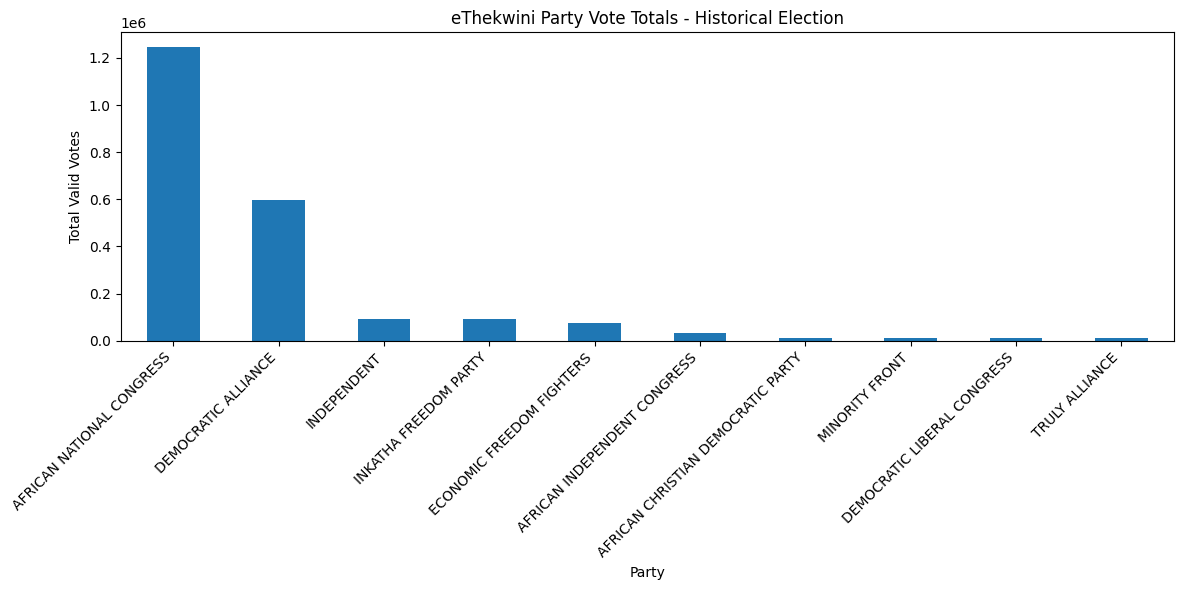

In [33]:
party_votes_2011 = (
    eth_2011
    .groupby("PartyName")["TotalValidVotes"]
    .sum()
    .sort_values(ascending=False)
)

party_votes_2011.head(10).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("eThekwini Party Vote Totals - Historical Election")
plt.xlabel("Party")
plt.ylabel("Total Valid Votes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Create a proper vote-share variable

In [34]:
ward_party_2011 = (
    eth_2011
    .groupby(
        ["Ward", "PartyName"],
        as_index=False
    )
    .agg(
        Votes=("TotalValidVotes", "sum"),
        RegisteredVoters=("RegisteredVoters", "max"),
        SpoiltVotes=("SpoiltVotes", "sum")
    )
)

In [35]:
ward_party_2011["WardTotalVotes"] = (
    ward_party_2011
    .groupby("Ward")["Votes"]
    .transform("sum")
)

In [36]:
ward_party_2011["VoteShare"] = (
    ward_party_2011["Votes"] /
    ward_party_2011["WardTotalVotes"]
)

display(ward_party_2011.head(20))

,Ward,PartyName,Votes,RegisteredVoters,SpoiltVotes,WardTotalVotes,VoteShare
0,Ward 59500001,ACADEMIC CONGRESS UNION,4,2142,882,24835,0.000161
1,Ward 59500001,AFRICAN CHRISTIAN DEMOCRATIC PARTY,15,2142,882,24835,0.000604
2,Ward 59500001,AFRICAN INDEPENDENT CONGRESS,444,2142,882,24835,0.017878
3,Ward 59500001,AFRICAN MANTUNGWA COMMUNITY,11,2142,553,24835,0.000443
4,Ward 59500001,AFRICAN NATIONAL CONGRESS,21026,2142,882,24835,0.846628
5,Ward 59500001,AFRICAN PEOPLE'S CONVENTION,41,2142,882,24835,0.001651
6,Ward 59500001,AL JAMA-AH,5,2142,882,24835,0.000201
7,Ward 59500001,ALLIED MOVEMENT FOR CHANGE,1,2142,553,24835,0.000040
8,Ward 59500001,AZANIAN PEOPLE'S ORGANISATION,4,2142,882,24835,0.000161
9,Ward 59500001,CONGRESS OF THE PEOPLE,6,2142,553,24835,0.000242


checking for output

In [41]:
print("Dataset 1 year:")
print(pd.to_datetime(df1["DateGenerated"], errors='coerce').dt.year.value_counts())

print("\nDataset 2 year:")
print(pd.to_datetime(df2["DateGenerated"], errors='coerce').dt.year.value_counts())

Dataset 1 year:
DateGenerated
2016    40706
Name: count, dtype: int64

Dataset 2 year:
DateGenerated
2011    24843
Name: count, dtype: int64


Rename the datasets clearly

In [44]:
df_2016 = df1.copy()
df_2011 = df2.copy()

print("2016:", df_2016.shape)
print("2011:", df_2011.shape)

2016: (40706, 11)
2011: (24843, 11)


Check the municipality

In [45]:
print("2016 municipalities:")
print(df_2016["Municipality"].unique())

print("\n2011 municipalities:")
print(df_2011["Municipality"].unique())

2016 municipalities:
['ETH - eThekwini']

2011 municipalities:
['ETH - eThekwini [Durban Metro]']


Filter eThekwini

In [46]:
eth_2016 = df_2016[
    df_2016["Municipality"].astype(str).str.contains(
        "eThekwini|ETH",
        case=False,
        na=False
    )
].copy()

eth_2011 = df_2011[
    df_2011["Municipality"].astype(str).str.contains(
        "eThekwini|ETH",
        case=False,
        na=False
    )
].copy()

print("2016 eThekwini:", eth_2016.shape)
print("2011 eThekwini:", eth_2011.shape)

2016 eThekwini: (40706, 11)
2011 eThekwini: (24843, 11)


Then verify:

In [47]:
print(eth_2016["Municipality"].unique())
print(eth_2011["Municipality"].unique())

['ETH - eThekwini']
['ETH - eThekwini [Durban Metro]']


Check the ward structure

In [48]:
print("2016 wards:", eth_2016["Ward"].nunique())
print("2011 wards:", eth_2011["Ward"].nunique())

print("\n2016 voting districts:", eth_2016["VotingDistrict"].nunique())
print("2011 voting districts:", eth_2011["VotingDistrict"].nunique())

2016 wards: 110
2011 wards: 103

2016 voting districts: 866
2011 voting districts: 801


In [49]:
print("2016 ward examples:")
print(sorted(eth_2016["Ward"].dropna().unique())[:20])

print("\n2011 ward examples:")
print(sorted(eth_2011["Ward"].dropna().unique())[:20])

2016 ward examples:
['Ward 59500001', 'Ward 59500002', 'Ward 59500003', 'Ward 59500004', 'Ward 59500005', 'Ward 59500006', 'Ward 59500007', 'Ward 59500008', 'Ward 59500009', 'Ward 59500010', 'Ward 59500011', 'Ward 59500012', 'Ward 59500013', 'Ward 59500014', 'Ward 59500015', 'Ward 59500016', 'Ward 59500017', 'Ward 59500018', 'Ward 59500019', 'Ward 59500020']

2011 ward examples:
['Ward 59500001', 'Ward 59500002', 'Ward 59500003', 'Ward 59500004', 'Ward 59500005', 'Ward 59500006', 'Ward 59500007', 'Ward 59500008', 'Ward 59500009', 'Ward 59500010', 'Ward 59500011', 'Ward 59500012', 'Ward 59500013', 'Ward 59500014', 'Ward 59500015', 'Ward 59500016', 'Ward 59500017', 'Ward 59500018', 'Ward 59500019', 'Ward 59500020']


Understand the party data

In [50]:
print("2016 parties:")
display(
    eth_2016["PartyName"]
    .value_counts()
    .head(20)
)

print("\n2011 parties:")
display(
    eth_2011["PartyName"]
    .value_counts()
    .head(20)
)

2016 parties:


,count
PartyName,
ACADEMIC CONGRESS UNION,1732
AFRICAN CHRISTIAN DEMOCRATIC PARTY,1732
AL JAMA-AH,1732
AFRICAN NATIONAL CONGRESS,1732
DEMOCRATIC ALLIANCE,1732
DEMOCRATIC LIBERAL CONGRESS,1732
MINORITY FRONT,1732
VRYHEIDSFRONT PLUS,1732
TRULY ALLIANCE,1732



2011 parties:


,count
PartyName,
AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ALLIANSIE,1602
AFRICAN CHRISTIAN DEMOCRATIC PARTY,1602
AFRICAN NATIONAL CONGRESS,1602
MINORITY FRONT,1602
VRYHEIDSFRONT PLUS,1602
TRULY ALLIANCE,1602
SOCIALIST GREEN COALITION,1602
UNITED ACTION FRONT,1590
INKATHA FREEDOM PARTY,1590


Check the numerical variables

In [51]:
numeric_cols = [
    "RegisteredVoters",
    "SpoiltVotes",
    "TotalValidVotes"
]

print("2016:")
display(eth_2016[numeric_cols].describe())

print("\n2011:")
display(eth_2011[numeric_cols].describe())

2016:


,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,40706.000000,40706.000000,40706.000000
mean,2218.242618,29.917383,54.675109
std,1216.222531,51.968268,231.244162
min,101.000000,0.000000,0.000000
25%,1376.000000,6.000000,0.000000
50%,2098.000000,17.000000,1.000000
75%,2827.000000,36.000000,6.000000
max,8099.000000,993.000000,4175.000000



2011:


,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,24843.000000,24843.000000,24843.000000
mean,2086.138107,17.688685,78.182224
std,1125.692140,20.507079,272.686536
min,129.000000,0.000000,0.000000
25%,1268.000000,5.000000,0.000000
50%,1987.000000,12.000000,2.000000
75%,2689.000000,24.000000,13.000000
max,7712.000000,297.000000,3577.000000


Make sure those columns are actually numeric:

In [ ]:
print(eth_2016[numeric_cols].dtypes)
print(eth_2011[numeric_cols].dtypes)

the modelling dataset

In [ ]:
ward_party_2016 = (
    eth_2016
    .groupby(["Ward", "PartyName"], as_index=False)
    .agg(
        Votes=("TotalValidVotes", "sum"),
        SpoiltVotes=("SpoiltVotes", "sum"),
        RegisteredVoters=("RegisteredVoters", "sum")
    )
)

In [39]:
ward_party_2011 = (
    eth_2011
    .groupby(["Ward", "PartyName"], as_index=False)
    .agg(
        Votes=("TotalValidVotes", "sum"),
        SpoiltVotes=("SpoiltVotes", "sum"),
        RegisteredVoters=("RegisteredVoters", "sum")
    )
)

Calculate ward vote totals

In [ ]:
ward_party_2016["WardTotalVotes"] = (
    ward_party_2016
    .groupby("Ward")["Votes"]
    .transform("sum")
)

ward_party_2011["WardTotalVotes"] = (
    ward_party_2011
    .groupby("Ward")["Votes"]
    .transform("sum")
)

Calculate party vote share

In [ ]:
ward_party_2016["VoteShare"] = (
    ward_party_2016["Votes"] /
    ward_party_2016["WardTotalVotes"]
)

ward_party_2011["VoteShare"] = (
    ward_party_2011["Votes"] /
    ward_party_2011["WardTotalVotes"]
)

In [ ]:
display(ward_party_2016.head(20))

Identify the historical ward winner

In [54]:
# 1. Build and calculate share for 2016
ward_party_2016 = (
    eth_2016
    .groupby(["Ward", "PartyName"], as_index=False)
    .agg(
        Votes=("TotalValidVotes", "sum"),
        SpoiltVotes=("SpoiltVotes", "sum"),
        RegisteredVoters=("RegisteredVoters", "sum")
    )
)
ward_party_2016["WardTotalVotes"] = (
    ward_party_2016
    .groupby("Ward")["Votes"]
    .transform("sum")
)
ward_party_2016["VoteShare"] = (
    ward_party_2016["Votes"] /
    ward_party_2016["WardTotalVotes"]
)

# 2. Build and calculate share for 2011
ward_party_2011 = (
    eth_2011
    .groupby(["Ward", "PartyName"], as_index=False)
    .agg(
        Votes=("TotalValidVotes", "sum"),
        SpoiltVotes=("SpoiltVotes", "sum"),
        RegisteredVoters=("RegisteredVoters", "sum")
    )
)
ward_party_2011["WardTotalVotes"] = (
    ward_party_2011
    .groupby("Ward")["Votes"]
    .transform("sum")
)
ward_party_2011["VoteShare"] = (
    ward_party_2011["Votes"] /
    ward_party_2011["WardTotalVotes"]
)

# 3. Identify the historical ward winners
winner_2016 = (
    ward_party_2016
    .loc[
        ward_party_2016.groupby("Ward")["VoteShare"].idxmax()
    ]
    [["Ward", "PartyName", "VoteShare"]]
    .rename(columns={
        "PartyName": "Winner2016",
        "VoteShare": "WinningVoteShare2016"
    })
)

winner_2011 = (
    ward_party_2011
    .loc[
        ward_party_2011.groupby("Ward")["VoteShare"].idxmax()
    ]
    [["Ward", "PartyName", "VoteShare"]]
    .rename(columns={
        "PartyName": "Winner2011",
        "VoteShare": "WinningVoteShare2011"
    })
)

display(winner_2016.head())

,Ward,Winner2016,WinningVoteShare2016
4,Ward 59500001,AFRICAN NATIONAL CONGRESS,0.846628
32,Ward 59500002,AFRICAN NATIONAL CONGRESS,0.886471
59,Ward 59500003,AFRICAN NATIONAL CONGRESS,0.620563
87,Ward 59500004,AFRICAN NATIONAL CONGRESS,0.475527
115,Ward 59500005,AFRICAN NATIONAL CONGRESS,0.854336


Aggregate party support across eThekwini

In [55]:
aggregate_2016 = (
    eth_2016
    .groupby("PartyName", as_index=False)["TotalValidVotes"]
    .sum()
    .rename(columns={"TotalValidVotes": "Votes2016"})
)

aggregate_2016["VoteShare2016"] = (
    aggregate_2016["Votes2016"] /
    aggregate_2016["Votes2016"].sum()
)

display(
    aggregate_2016
    .sort_values("Votes2016", ascending=False)
    .head(15)
)

,PartyName,Votes2016,VoteShare2016
4,AFRICAN NATIONAL CONGRESS,1246512,0.560078
10,DEMOCRATIC ALLIANCE,599073,0.269173
13,INDEPENDENT,93432,0.041980
16,INKATHA FREEDOM PARTY,93414,0.041972
12,ECONOMIC FREEDOM FIGHTERS,76639,0.034435
2,AFRICAN INDEPENDENT CONGRESS,30445,0.013679
1,AFRICAN CHRISTIAN DEMOCRATIC PARTY,12103,0.005438
18,MINORITY FRONT,11795,0.005300
11,DEMOCRATIC LIBERAL CONGRESS,11515,0.005174
23,TRULY ALLIANCE,9138,0.004106


In [ ]:
aggregate_2011 = (
    eth_2011
    .groupby("PartyName", as_index=False)["TotalValidVotes"]
    .sum()
    .rename(columns={"TotalValidVotes": "Votes2011"})
)

aggregate_2011["VoteShare2011"] = (
    aggregate_2011["Votes2011"] /
    aggregate_2011["Votes2011"].sum()
)

display(
    aggregate_2011
    .sort_values("Votes2011", ascending=False)
    .head(15)
)

Visualise historical party support

In [ ]:
top_parties = (
    aggregate_2016
    .sort_values("Votes2016", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_parties["PartyName"],
    top_parties["VoteShare2016"]
)

plt.title("eThekwini 2016 Historical Party Vote Share")
plt.xlabel("Party")
plt.ylabel("Vote Share")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Create a historical comparison

In [ ]:
party_history = pd.merge(
    aggregate_2011,
    aggregate_2016,
    on="PartyName",
    how="outer"
).fillna(0)

party_history["VoteShareChange"] = (
    party_history["VoteShare2016"] -
    party_history["VoteShare2011"]
)

display(
    party_history
    .sort_values("Votes2016", ascending=False)
    .head(15)
)

In [ ]:
party = "ANC"

Check the ballot types

In [ ]:
print("2016 ballot types:")
print(eth_2016["BallotType"].value_counts(dropna=False))

print("\n2011 ballot types:")
print(eth_2011["BallotType"].value_counts(dropna=False))

Inspect one voting district

In [ ]:
sample_vd = eth_2016["VotingDistrict"].dropna().iloc[0]

display(
    eth_2016[
        eth_2016["VotingDistrict"] == sample_vd
    ][[
        "Ward",
        "VotingDistrict",
        "BallotType",
        "PartyName",
        "RegisteredVoters",
        "SpoiltVotes",
        "TotalValidVotes"
    ]].sort_values(["BallotType", "PartyName"])
)

Check whether TotalValidVotes changes between parties

In [ ]:
check_votes = (
    eth_2016
    .groupby(["VotingDistrict", "BallotType"])["TotalValidVotes"]
    .nunique()
)

print(check_votes.value_counts())

Create clean numeric columns

In [ ]:
for df in [eth_2011, eth_2016]:
    for col in ["RegisteredVoters", "SpoiltVotes", "TotalValidVotes"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric columns cleaned.")